<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
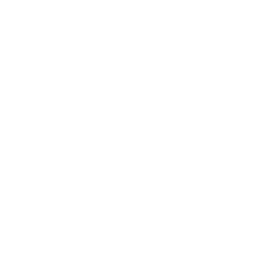
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Utilização de Recursos por Departamento Hospitalar — Gráfico de Barras Horizontais</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Saúde / Operações Hospitalares &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Este exemplo usa **PROC GCHART** com gráficos de barras horizontais (HBAR) para analisar as horas de equipe em seis departamentos clínicos no T1 2026. Um registro sintético de força de trabalho com **90 registros de turno** (15 por departamento) alimenta três visões: um gráfico de barras com o total de horas ordenado, a duração média do turno por departamento, e gráficos HBAR agrupados que dividem cada departamento por categoria de recurso e por turno. `SUMVAR=` acumula as horas de trabalho reais em vez de contar registros, `TYPE=SUM`/`TYPE=MEAN` alterna a estatística de resposta, `DESCENDING` ordena os departamentos, e `GROUP=` desenha barras agrupadas adjacentes para uma segunda dimensão.

A saída apoia a revisão trimestral de eficiência operacional: ela revela quais departamentos consomem mais mão de obra, quais têm os turnos mais longos, e como o padrão de escala diurno/vespertino/noturno difere entre unidades de acuidade contínua e serviços diurnos.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Registros individuais de turno com horas trabalhadas | 90 |
| WORK.DEPT_SUMMARY | Totais por departamento e duração média do turno | 6 |

---

In [1]:
/* --------------------------------------------------------
   Gera um registro sintético de escalas de trabalho hospitalar.
   T1 2026: 6 departamentos clínicos, 4 categorias de recurso,
   3 turnos. Dimensionado para 15 registros de turno por
   departamento (90 no total) para manter visível o quadro
   completo de departamentos.
   -------------------------------------------------------- */
DADOS work.staffing_log;
    CHAMAR streaminit(20260601);
    COMPRIMENTO department $20 resource_type $16 shift $6;

    /* resource-category mix (nursing-heavy clinical staffing) */
    VETOR resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* baseline shift mix, tilted toward Night for 24/7 units */
    VETOR shfw[3] _temporary_ (0.45 0.30 0.25);
    VETOR nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    FAZER di = 1 ATÉ 6;
        /* department assigned via IF/ELSE (not a _temporary_ array) --
           avoids truncation of non-ASCII values by the array lookup */
        SE di = 1 ENTÃO department = 'Emergência';
        SENÃO SE di = 2 ENTÃO department = 'Cirurgia';
        SENÃO SE di = 3 ENTÃO department = 'UTI';
        SENÃO SE di = 4 ENTÃO department = 'Pediatria';
        SENÃO SE di = 5 ENTÃO department = 'Oncologia';
        SENÃO SE di = 6 ENTÃO department = 'Maternidade';
        FAZER rec = 1 ATÉ 15;

            /* resource type via weighted draw */
            u = rand('uniform'); cum = 0;
            FAZER r = 1 ATÉ 4;
                cum + resw[r];
                SE u <= cum ENTÃO FAZER;
                    /* resource type assigned via IF/ELSE (not a
                       _temporary_ array) -- avoids truncation of
                       non-ASCII values by the array lookup */
                    SE r = 1 ENTÃO resource_type = 'Enfermagem';
                    SENÃO SE r = 2 ENTÃO resource_type = 'Médico';
                    SENÃO SE r = 3 ENTÃO resource_type = 'Saúde Aliada';
                    SENÃO resource_type = 'Apoio';
                    SAIR;
                FIM;
            FIM;

            /* shift via department-specific night tilt */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            SE u <= w1 ENTÃO shift = 'Dia';
            SENÃO SE u <= w1 + w2 ENTÃO shift = 'Tarde';
            SENÃO shift = 'Noite';

            /* hours: physicians and surgery run longer shifts */
            BASE = 8;
            SE resource_type = 'Médico' ENTÃO BASE = BASE + 1.5;
            SE department = 'Cirurgia'  ENTÃO BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            SE hours_worked < 4 ENTÃO hours_worked = 4;

            SAÍDA;
        FIM;
    FIM;
    MANTER department resource_type shift hours_worked;
EXECUTAR;



NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


In [2]:
/* --------------------------------------------------------
   Totais por departamento e duração média do turno,
   ordenados pelo total de horas de trabalho.
   -------------------------------------------------------- */
PROCEDIMENTO SQL;
    CRIAR TABELA work.dept_summary AS
    SELECIONAR department,
           sum(hours_worked)  AS total_hours   FORMATO=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  FORMATO=6.2
    DE_TABELA work.staffing_log
    GROUP POR department
    ORDER POR total_hours DESC;
QUIT;

PROCEDIMENTO IMPRIMIR DADOS=work.dept_summary noobs RÓTULO;
    RÓTULO department    = 'Departamento'
          total_hours   = 'Total de Horas'
          shift_count   = 'Turnos'
          avg_shift_hrs = 'Turno Médio (h)';
    TÍTULO 'Resumo de Mão de Obra por Departamento - T1 2026';
EXECUTAR;
TÍTULO;


                                    Resumo de Mão de Obra por Departamento - T1 2026                                    

Departamento  Total de Horas  Turnos   Turno Médio (h)
Cirurgia              136.25      15              9.08
UTI                   128.50      15              8.57
Maternidade           127.75      15              8.52
Pediatria             124.75      15              8.32
Oncologia             123.75      15              8.25
Emergência            119.25      15              7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                           Horas de Trabalho por Departamento                                           

                                                  The MEANS Procedure

                                   Analysis Variable : hours_worked Horas Trabalhadas

        Departamento            Sum           Mean          N Obs
        ---------------------------------------------------------
        Cirurgia             136.25           9.08             15
        Emergência           119.25           7.95             15
        Maternidade          127.75           8.52             15
        Oncologia            123.75           8.25             15
        Pediatria            124.75           8.32             15
        UTI                  128.50           8.57             15
        ---------------------------------------------------------

                                        Distribuição de Turnos por Departamento                                         

   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


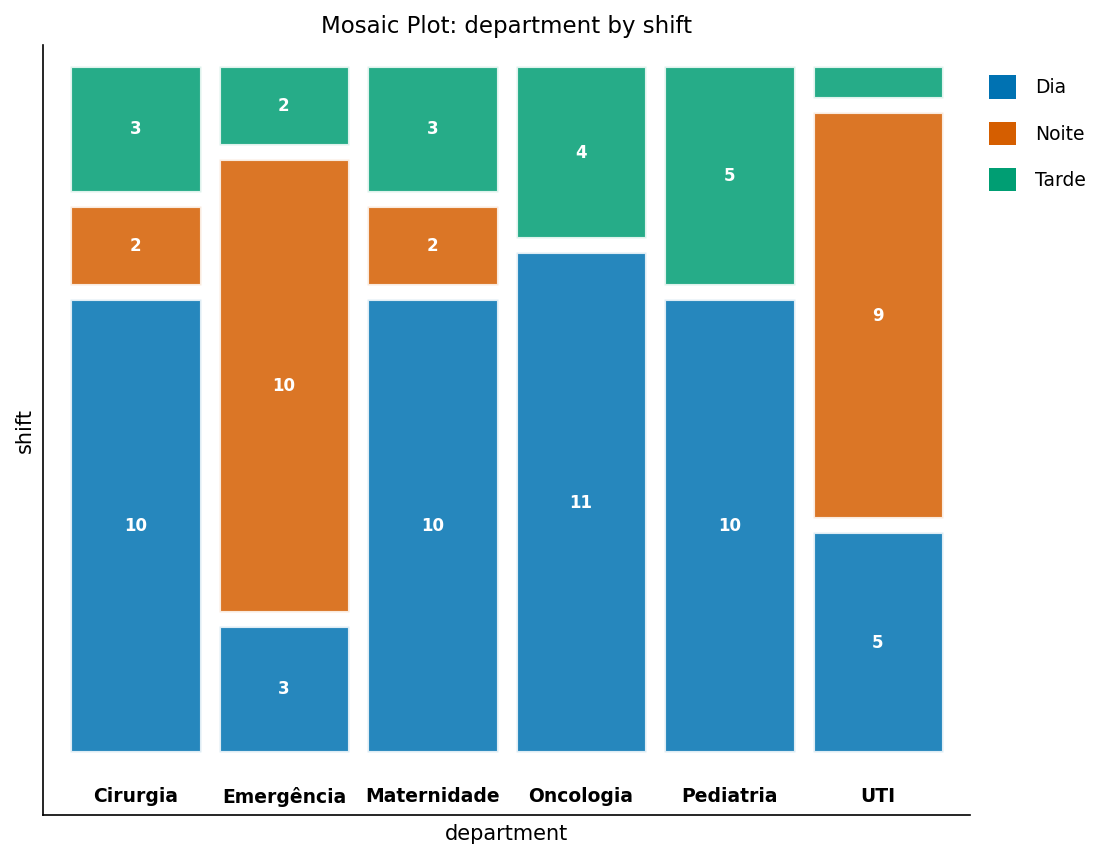

In [3]:
/* --------------------------------------------------------
   Tabelas de referência: horas de trabalho por departamento,
   e a distribuição de turnos diurno / vespertino / noturno
   por departamento.
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.staffing_log sum mean n maxdec=2;
    CLASSE department;
    VARIÁVEL hours_worked;
    RÓTULO department   = 'Departamento'
          hours_worked = 'Horas Trabalhadas';
    TÍTULO 'Horas de Trabalho por Departamento';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    RÓTULO department = 'Departamento'
          shift       = 'Turno';
    TÍTULO 'Distribuição de Turnos por Departamento';
EXECUTAR;
TÍTULO;


---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


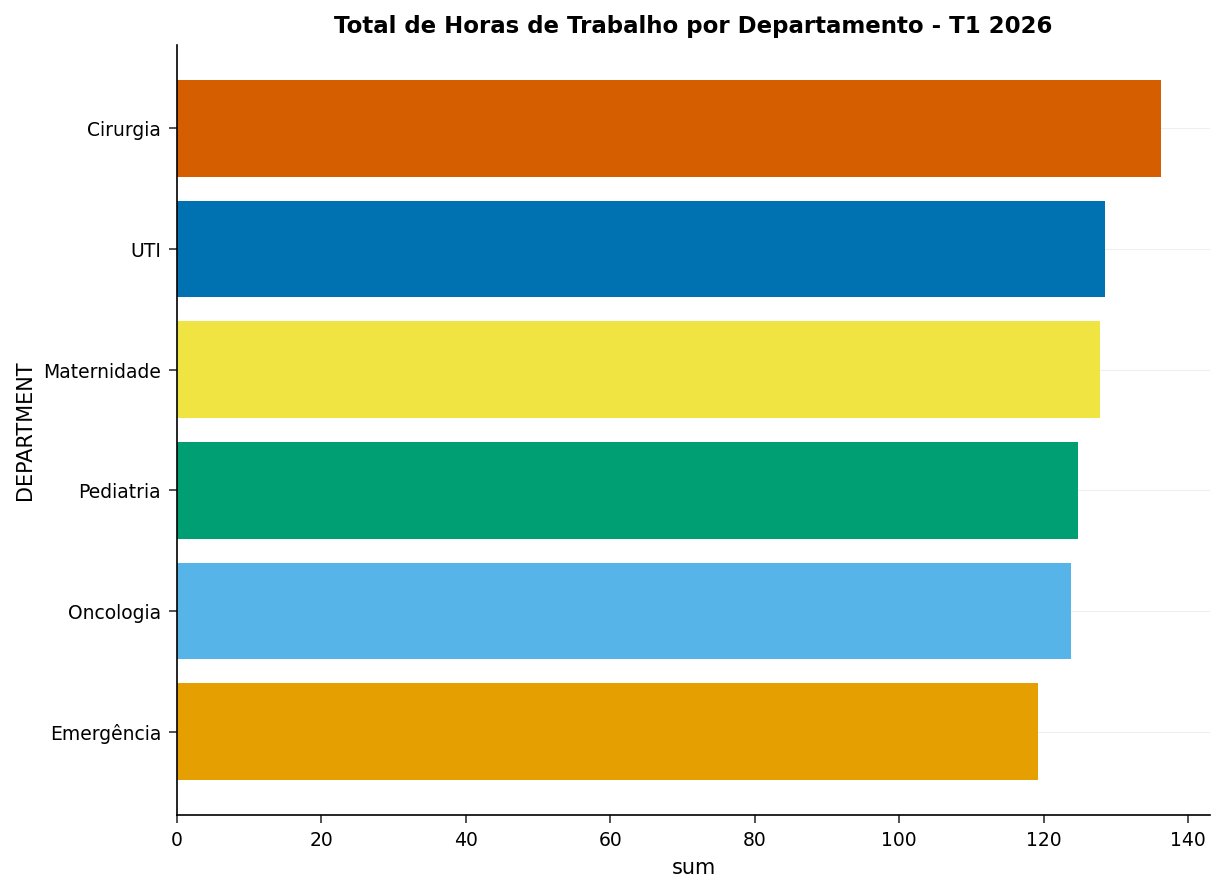

In [4]:
/* --------------------------------------------------------
   HBAR geral: total de horas de trabalho por departamento.
   SUMVAR= acumula as horas; DESCENDING ordena as barras.
   -------------------------------------------------------- */
PROCEDIMENTO GCHART DADOS=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      DECRESCENTE;
    RÓTULO department = 'Departamento';
    TÍTULO 'Total de Horas de Trabalho por Departamento - T1 2026';
EXECUTAR;
QUIT;
TÍTULO;


### Dividindo cada departamento por categoria de recurso

`GROUP=` desenha um agrupamento de barras horizontais adjacentes para cada departamento, uma barra por categoria de recurso. Como `SUMVAR=hours_worked` está em vigor, cada barra mede as horas de trabalho acumuladas em vez de uma contagem de registros, então o gráfico mostra como as horas de enfermagem, médicos, saúde aliada e apoio se comparam *dentro de* cada departamento.

In [5]:
/* --------------------------------------------------------
   Instruções PATTERN: paleta coordenada de 4 cores,
   um padrão por subgrupo de categoria de recurso
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Enfermagem -- azul profundo */
pattern2 VALUE=solid color=cx28A745;   /* Médico -- verde             */
pattern3 VALUE=solid color=cxE8650A;   /* Saúde Aliada -- âmbar       */
pattern4 VALUE=solid color=cx6C757D;   /* Apoio -- cinza              */


                               Horas de Trabalho por Departamento e Categoria de Recurso                                


Fonte: Sistema de Gestão de Força de Trabalho | Período do relatório: Jan-Mar 2026



NOTE: Option TITLE changed to Horas de Trabalho por Departamento e Categoria de Recurso.
NOTE: Option FOOTNOTE changed to Fonte: Sistema de Gestão de Força de Trabalho | Período do relatório: Jan-Mar 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


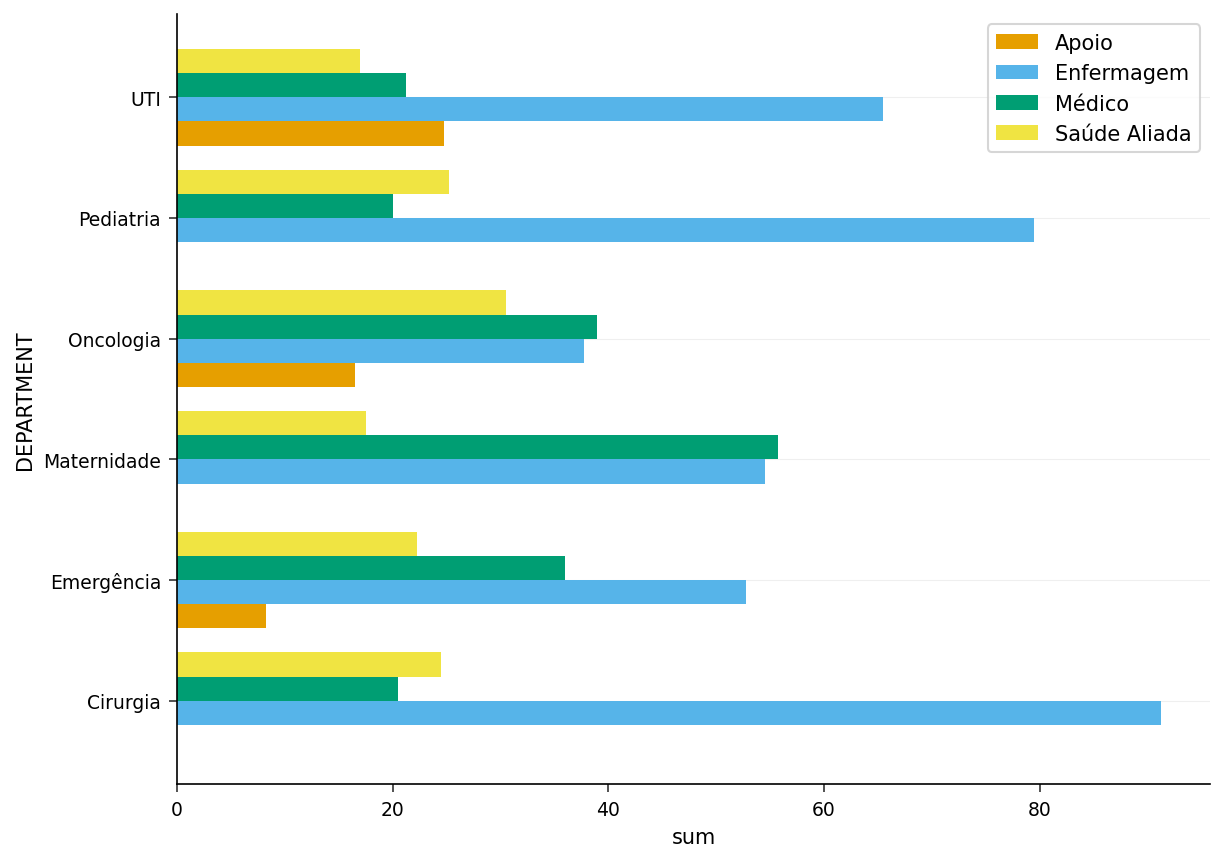

In [6]:
/* --------------------------------------------------------
   HBAR agrupado por categoria de recurso (GROUP=).
   Cada departamento se torna um agrupamento de barras -- uma
   por categoria de recurso -- medido em horas de trabalho
   acumuladas.
   -------------------------------------------------------- */
TÍTULO 'Horas de Trabalho por Departamento e Categoria de Recurso';
footnote JUSTIFY=LEFT
    'Fonte: Sistema de Gestão de Força de Trabalho | Período do relatório: Jan-Mar 2026';

PROCEDIMENTO GCHART DADOS=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
    RÓTULO department     = 'Departamento'
          resource_type  = 'Categoria de Recurso';
EXECUTAR;
QUIT;

TÍTULO; footnote;


                                       Horas de Trabalho por Departamento e Turno                                       


Barras agrupadas separam as contribuições de Dia / Tarde / Noite por departamento



NOTE: Option TITLE changed to Horas de Trabalho por Departamento e Turno.
NOTE: Option FOOTNOTE changed to Barras agrupadas separam as contribuições de Dia / Tarde / Noite por departamento.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


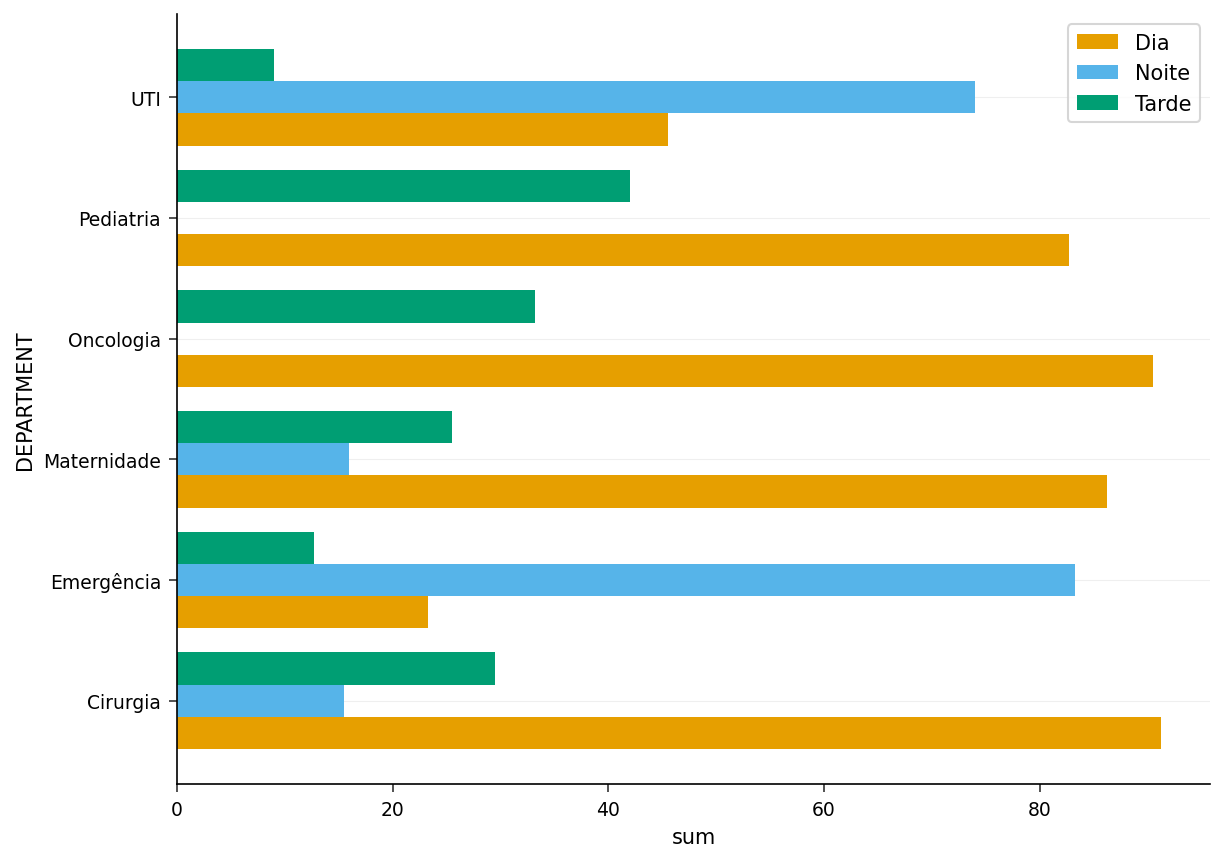

In [7]:
/* --------------------------------------------------------
   HBAR agrupado por turno (GROUP=).
   Separa as horas de trabalho Diurno / Vespertino / Noturno
   dentro de cada departamento -- destacando as unidades de
   acuidade contínua (24/7).
   -------------------------------------------------------- */
TÍTULO 'Horas de Trabalho por Departamento e Turno';
footnote JUSTIFY=LEFT
    'Barras agrupadas separam as contribuições de Dia / Tarde / Noite por departamento';

PROCEDIMENTO GCHART DADOS=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
    RÓTULO department = 'Departamento'
          shift       = 'Turno';
EXECUTAR;
QUIT;

TÍTULO; footnote;



NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


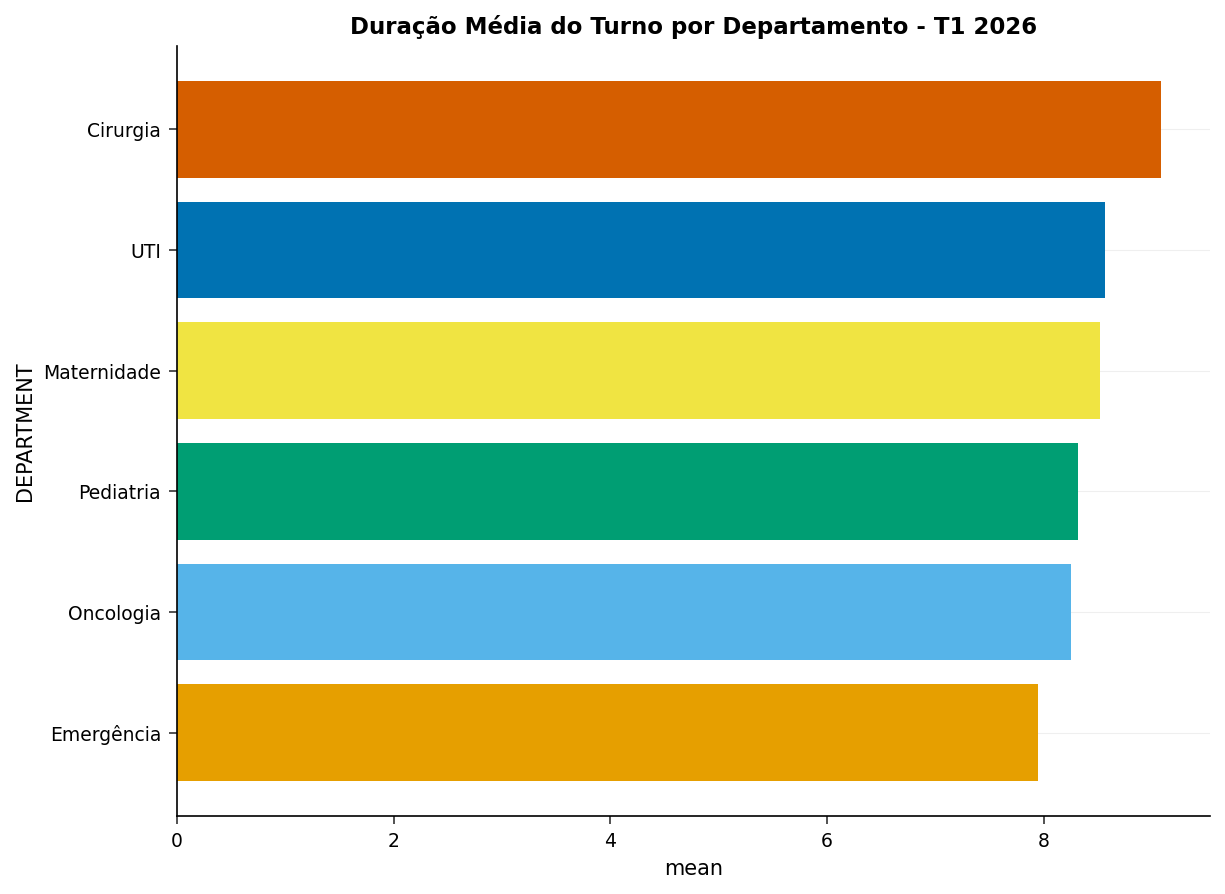

In [8]:
/* --------------------------------------------------------
   Duração média do turno por departamento (TYPE=MEAN).
   Revela se um departamento roda turnos longos ou muitos
   turnos mais curtos, independentemente do volume total.
   -------------------------------------------------------- */
PROCEDIMENTO GCHART DADOS=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      DECRESCENTE;
    RÓTULO department = 'Departamento';
    TÍTULO 'Duração Média do Turno por Departamento - T1 2026';
EXECUTAR;
QUIT;
TÍTULO;


---

### Interpretação

Nos 90 registros de turno, o total de horas de trabalho fica numa faixa estreita entre **119,25** (Emergência) e **136,25** (Cirurgia), porque todo departamento carrega os mesmos 15 turnos neste período — então a classificação reflete a **duração do turno**, não a contagem de turnos. Cirurgia lidera tanto o gráfico de total de horas quanto o de turno médio, com **9,08 horas** por turno, consistente com casos operatórios mais longos e a escala com predomínio médico que esses casos exigem. Emergência fica na base em horas (média de **7,95**) apesar de ser uma das unidades mais movimentadas, porque seu trabalho é entregue em turnos mais curtos e de maior rotatividade.

O HBAR agrupado por turno e o painel de mosaico contam a história operacionalmente importante. **Emergência e UTI são predominantemente noturnas** — 10 de 15 e 9 de 15 turnos, respectivamente, caem à Noite — enquanto **Oncologia e Pediatria não registram nenhum turno Noturno** e se concentram na cobertura Diurna (11 e 10 turnos de Dia). Essa divisão reflete a escala hospitalar real: unidades de acuidade contínua funcionam ininterruptamente, enquanto a infusão de oncologia e a pediatria geral são serviços diurnos. O painel de categoria de recurso confirma uma **combinação liderada pela enfermagem** em todo departamento, com as horas de médicos e de saúde aliada formando os níveis secundários.

Para a revisão de escala do T2, a concentração de turnos noturnos em Emergência e UTI é o item a observar: é onde se acumulam os custos de taxa premium e gestão de fadiga, e onde qualquer mudança na rotação tem o maior impacto orçamentário.

---

In [9]:
/* --------------------------------------------------------
   Exporta o resumo do departamento para o sistema de
   planejamento de força de trabalho.
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
EXECUTAR;



NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>